The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


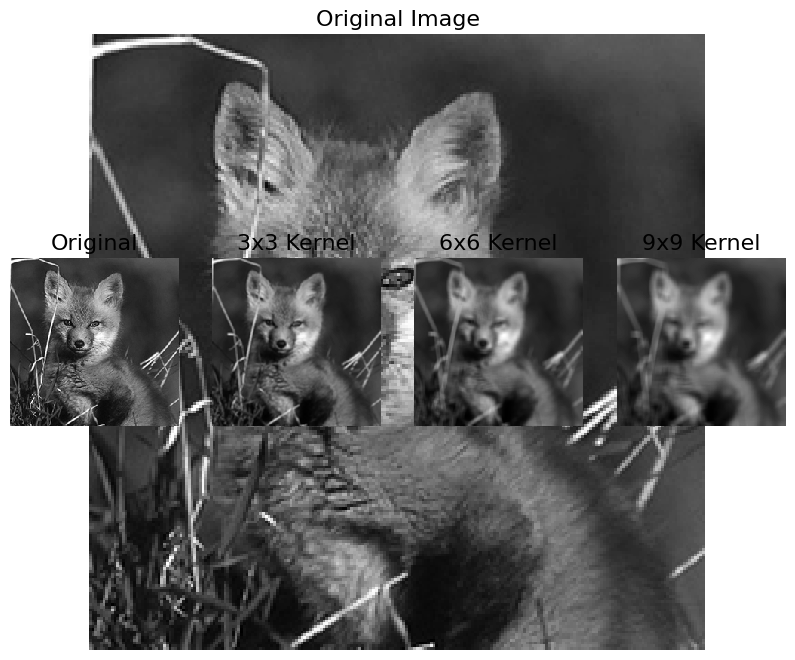

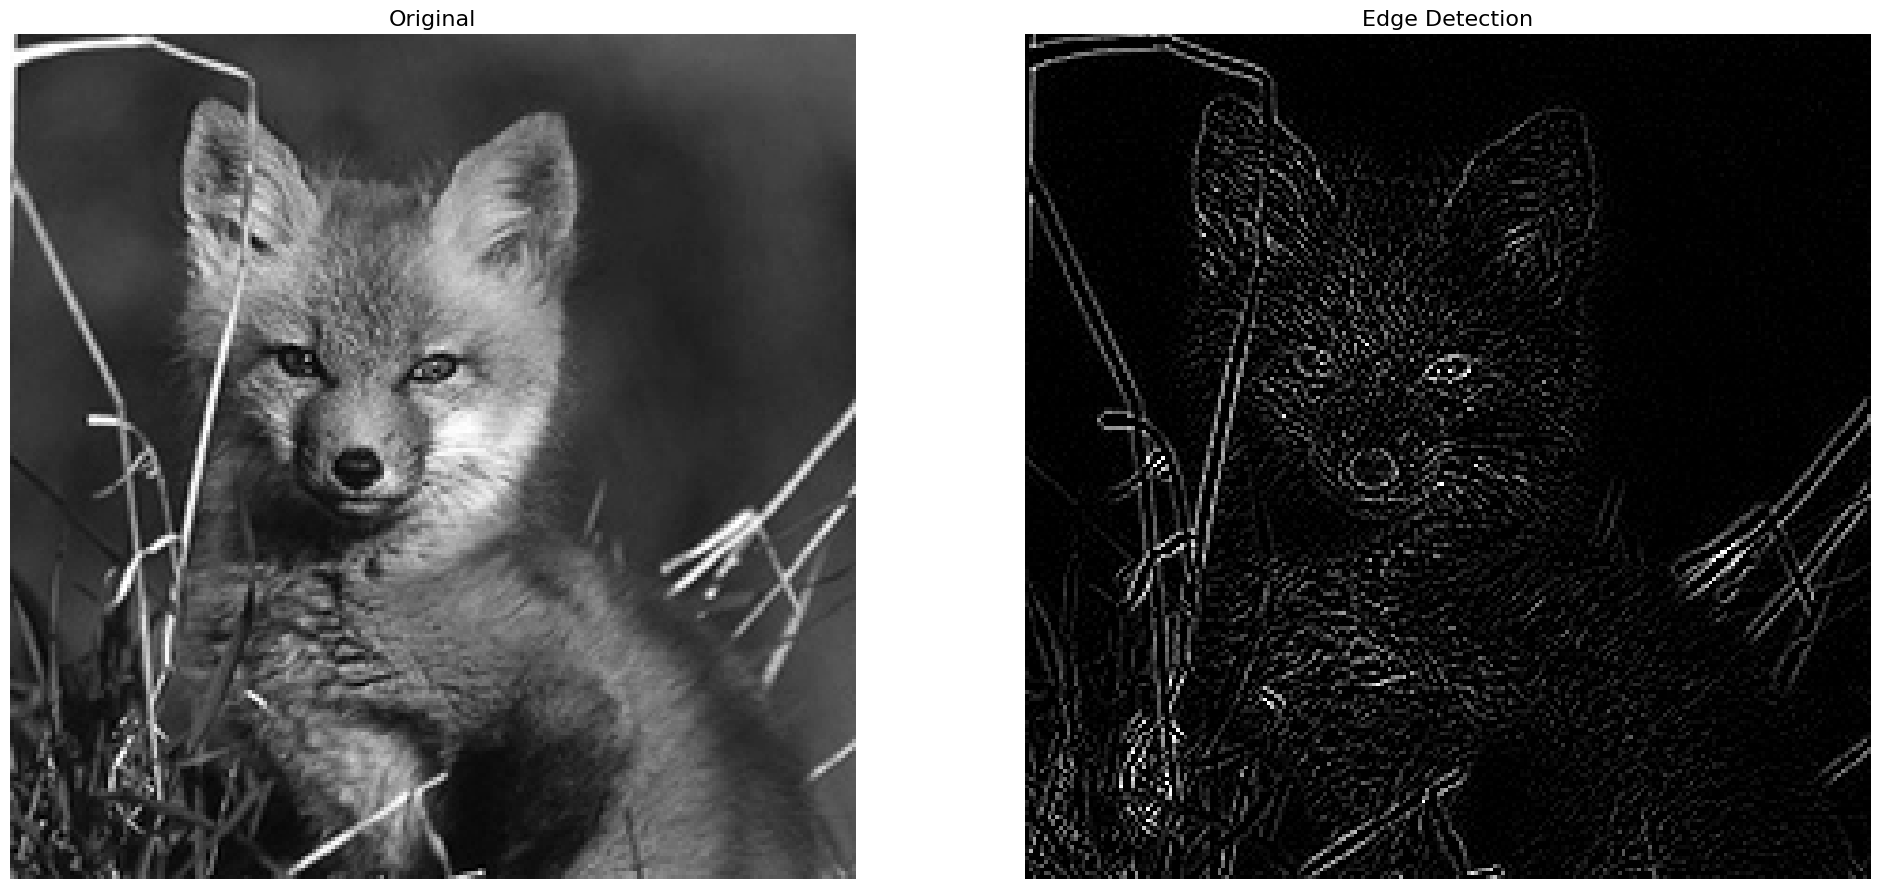

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import requests
import random
import torch
from PIL import Image
from scipy import ndimage

seed = 7
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

def show_image(image, title=''):
    image = torch.tensor(image)
    plt.imshow(torch.clip((image) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def show_multiple_images(images=[], titles=[]):
    assert len(images) == len(titles), "length of two inputs are not equal"
    N = len(images)
    plt.rcParams['figure.figsize'] = [24, 24]
    for i in range(N):
        plt.subplot(1, N, i+1)
        show_image(images[i], titles[i])
    plt.show()

def rgb2gray(rgb):
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray

img_url = 'https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg'
img = Image.open(requests.get(img_url, stream=True).raw)
img = np.array(img) / 255
gray_img = rgb2gray(img)

show_image(gray_img, 'Original Image')

def averaging_filtering(image, filter_size=3):
    kernel = np.ones((filter_size, filter_size)) / (filter_size * filter_size)
    output = ndimage.convolve(image, kernel)
    return output

avg_images, avg_titles = [gray_img], ['Original']
for kernel_size in [3, 6, 9]:
    averaging_image = averaging_filtering(gray_img, kernel_size)
    avg_images.append(averaging_image)
    avg_titles.append(f'{kernel_size}x{kernel_size} Kernel')

show_multiple_images(avg_images, avg_titles)

def edge_detecting(image):
    # Laplacian derivative filter.                               #

    kernel = np.array([[0,  1,  0],
                       [1, -4,  1],
                       [0,  1,  0]])
    output = ndimage.convolve(image, kernel)
    return output

edge_images, edge_titles = [gray_img], ['Original']
edge_image = edge_detecting(gray_img)
edge_images.append(edge_image)
edge_titles.append('Edge Detection')

show_multiple_images(edge_images, edge_titles)
